<a href="https://colab.research.google.com/github/xbanuelos/BI-Portfolio/blob/main/phase_01/project_04_seller_ranking/seller_ranking_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 04 - Seller Ranking Algorithm

**Dataset:** Olist Brazilean E-Commerce (Kaggle)

**Business Questions**

1. Wich seller perform best overall? 2. What metrics define a "good" seller?

The top seller scores 0.950 out of 1.0, excelling across all 4 metrics simultaneously. No single metric define a great seller, but the best one combine high review scores, strong on-time rates, solid volume, and competitive freight costs.

3. Does the ranking change significatly when business priorities shift (e.g. priorizing quality over speed, or volume over reliability)?

The ranking is stable. Top 5 sellers remain unchaing across both weight schemes (quality-focused vs reliability-focus). Only mino shifts appear from rank 6 onward, suggesting the best sellers are genuinely well rounded.


**Metrics to score**

- Average review score (quality)

- Order volumne (popularity)

- On-time delivery rate (reliability)

- Average freight value (cost efficency)

**Project Conclusion**

A compsite scoring model is more fair and robust than ranking by a single metric like reviews or volume alone. The 4-metric weighted model identifies sellers that deliver constant value acros quality, reliability, popularity, and cost.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

order_items = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_order_reviews_dataset.csv')
order = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_orders_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_customers_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_products_dataset.csv')
cat_translation = pd.read_csv('/content/drive/MyDrive/BI Portfolio/product_category_name_translation.csv')
sellers = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_sellers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/BI Portfolio/olist_geolocation_dataset.csv')

In [28]:
# Convertir fechas
order[['order_delivered_customer_date', 'order_estimated_delivery_date']] = order[['order_delivered_customer_date', 'order_estimated_delivery_date']].apply(pd.to_datetime)

#Solo órdenes entregadas
delivered = order[order['order_status'] == 'delivered'].copy()

delivered['is_late'] = delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']

In [29]:
#Unir todo

df = order_items.merge(delivered[['order_id','is_late']], on='order_id',how='inner').merge(order_payments, on='order_id')
df = df.merge(order_reviews[['order_id','review_score']], on='order_id', how='left')

In [30]:
from re import A
#Calcular métricas por seller
seller_metrics = df.groupby('seller_id').agg(
    avg_review_score = ('review_score','mean'),
    order_volume = ('order_id','count'),
    on_time_rate = ('is_late', lambda x: (x == False).mean()),
    avg_freight_value = ('freight_value','mean')
).reset_index().round(3)

#Solo sellers con volumen significativo
seller_metrics = seller_metrics[seller_metrics['order_volume'] >= 10]

print(seller_metrics.shape)
print(seller_metrics.head())

(1381, 5)
                          seller_id  avg_review_score  order_volume  \
1  001cca7ae9ae17fb1caed9dfb1094831             3.974           236   
2  002100f778ceb8431b7a1020ff7ab48f             4.086            58   
4  004c9cd9d87a3c30c522c48c4fc07416             4.123           206   
5  00720abe85ba0859807595bbf045a33b             3.654            26   
8  00ee68308b45bc5e2660cd833c3f81cc             4.293           189   

   on_time_rate  avg_freight_value  
1         0.945             36.984  
2         0.845             14.193  
4         0.927             25.071  
5         0.923             12.153  
8         0.921             17.922  


In [31]:
# Invertir freight — menor es mejor
seller_metrics['avg_freight_value'] = 1 - seller_metrics['avg_freight_value']

In [32]:
#Normalizar cada metrica

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

#Columnas a normalizar
metrics_cols = ['avg_review_score', 'order_volume', 'on_time_rate', 'avg_freight_value']

#Normalizar
seller_metrics[metrics_cols] = scaler.fit_transform(seller_metrics[metrics_cols])

print(seller_metrics.head())

                          seller_id  avg_review_score  order_volume  \
1  001cca7ae9ae17fb1caed9dfb1094831          0.715000      0.107312   
2  002100f778ceb8431b7a1020ff7ab48f          0.746111      0.022792   
4  004c9cd9d87a3c30c522c48c4fc07416          0.756389      0.093067   
5  00720abe85ba0859807595bbf045a33b          0.626111      0.007597   
8  00ee68308b45bc5e2660cd833c3f81cc          0.803611      0.084995   

   on_time_rate  avg_freight_value  
1      0.914463           0.806129  
2      0.758942           0.929606  
4      0.886470           0.870671  
5      0.880249           0.940659  
8      0.877138           0.909403  


In [34]:
#Pesos - deben supar 1.0 priorizando review score
weights = {
    'avg_review_score': 0.35, # cantidad es lo más importante
    'on_time_rate': 0.30,     # confiabilidad
    'order_volume': 0.20,     # popularidad
    'avg_freight_value': 0.25 # rentabilidad
}

#Score final
seller_metrics['final_score'] = (
    seller_metrics['avg_review_score'] * weights['avg_review_score'] +
    seller_metrics['on_time_rate'] * weights['on_time_rate'] +
    seller_metrics['order_volume'] * weights['order_volume'] +
    seller_metrics['avg_freight_value'] * weights['avg_freight_value']
).round(3)

#Rankear
seller_metrics = seller_metrics.sort_values('final_score', ascending=False)
seller_metrics['rank'] = range(1,len(seller_metrics) + 1)

print(seller_metrics[['rank','seller_id','final_score']].head(10))

      rank                         seller_id  final_score
1190     1  6560211a19b47992c3666cc44a7e94c0        0.950
2388     2  cc419e0650a3c5ba77189a1882b7556a        0.942
358      3  1f50f920176fa81dab994f9023523100        0.922
2543     4  da8622b14eb17ae2831f4ac5b9dab84a        0.914
858      5  4a3ca9315b744ce9f8e9374361493884        0.914
140      6  0b36063d5818f81ccb94b54adfaebbf5        0.900
1758     7  955fee9216a65b617aa5c0531780ce60        0.895
1450     8  7a67c85e85bb2ce8582c35f2203ad736        0.895
840      9  48efc9d94a9834137efd9ea76b065a38        0.891
1987    10  ab27bbbad5239bc31a34709275a70db4        0.889


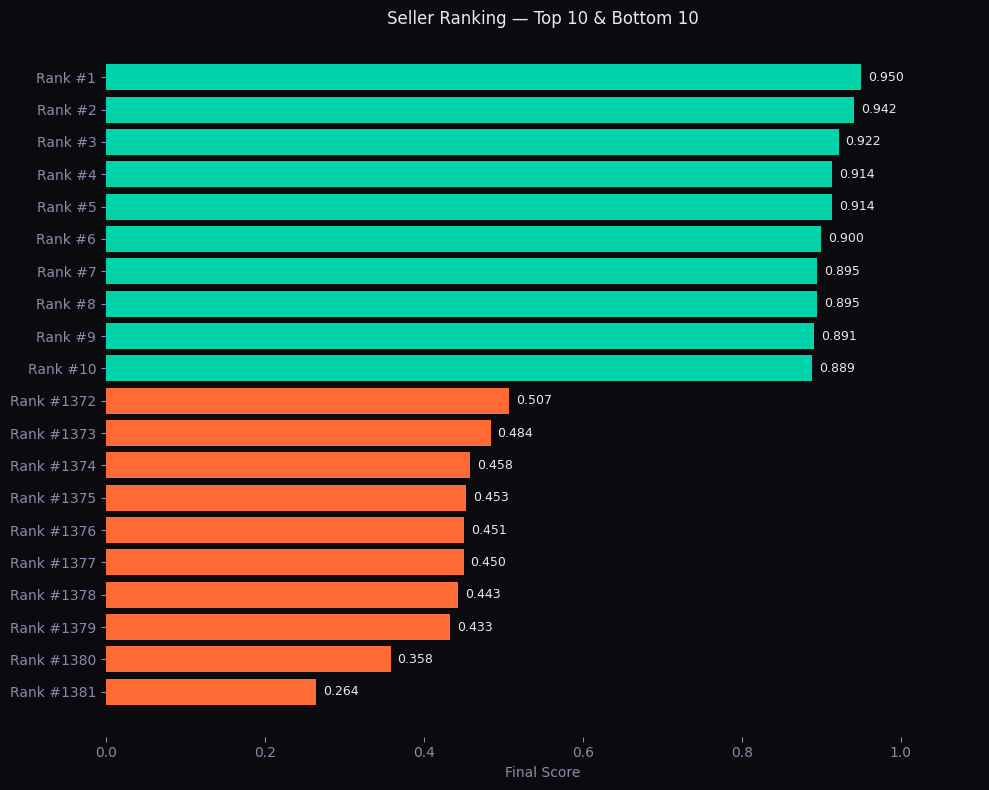

In [35]:
top10 = seller_metrics.head(10)
bottom10 = seller_metrics.tail(10)
top_bottom = pd.concat([top10,bottom10])

# Etiqueta corta para el eje Y
top_bottom['seller_label'] = 'Rank #' + top_bottom['rank'].astype(str)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top_bottom['seller_label'],
               top_bottom['final_score'],
               color=['#00d4aa' if r <= 10 else '#ff6b35'
                      for r in top_bottom['rank']])

ax.bar_label(bars, labels=[f"{s:.3f}" for s in top_bottom['final_score']],
             padding=5, color='#e8e8f0', fontsize=9)

ax.set_title('Seller Ranking — Top 10 & Bottom 10', color='#e8e8f0')
ax.set_xlabel('Final Score', color='#8a8aaa')
ax.set_xlim(0, 1.1)
ax.invert_yaxis()
ax.set_facecolor('#0a0a0f')
fig.patch.set_facecolor('#0a0a0f')
ax.tick_params(colors='#8a8aaa')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
# Escenario 2 — priorizando velocidad de entrega
weights_2 = {
    'avg_review_score': 0.20,
    'on_time_rate':     0.50,
    'order_volume':     0.20,
    'avg_freight_value': 0.10
}

seller_metrics['score_2'] = (
    seller_metrics['avg_review_score'] * weights_2['avg_review_score'] +
    seller_metrics['on_time_rate']     * weights_2['on_time_rate'] +
    seller_metrics['order_volume']     * weights_2['order_volume'] +
    seller_metrics['avg_freight_value'] * weights_2['avg_freight_value']
).round(3)

# Comparar top 10 original vs rappi style
seller_metrics['rank_2'] = seller_metrics['score_2']\
                                    .rank(ascending=False).astype(int)

# Ver cuánto cambia el ranking
comparison = seller_metrics[['seller_id', 'rank', 'rank_2',
                                   'final_score', 'score_2']].head(10)
print(comparison)


                             seller_id  rank  rank_2  final_score  score_2
1190  6560211a19b47992c3666cc44a7e94c0     1       1        0.950    0.884
2388  cc419e0650a3c5ba77189a1882b7556a     2       2        0.942    0.870
358   1f50f920176fa81dab994f9023523100     3       3        0.922    0.848
2543  da8622b14eb17ae2831f4ac5b9dab84a     4       4        0.914    0.843
858   4a3ca9315b744ce9f8e9374361493884     5       4        0.914    0.843
140   0b36063d5818f81ccb94b54adfaebbf5     6       9        0.900    0.800
1758  955fee9216a65b617aa5c0531780ce60     7       7        0.895    0.820
1450  7a67c85e85bb2ce8582c35f2203ad736     8       6        0.895    0.821
840   48efc9d94a9834137efd9ea76b065a38     9      10        0.891    0.798
1987  ab27bbbad5239bc31a34709275a70db4    10      11        0.889    0.796
